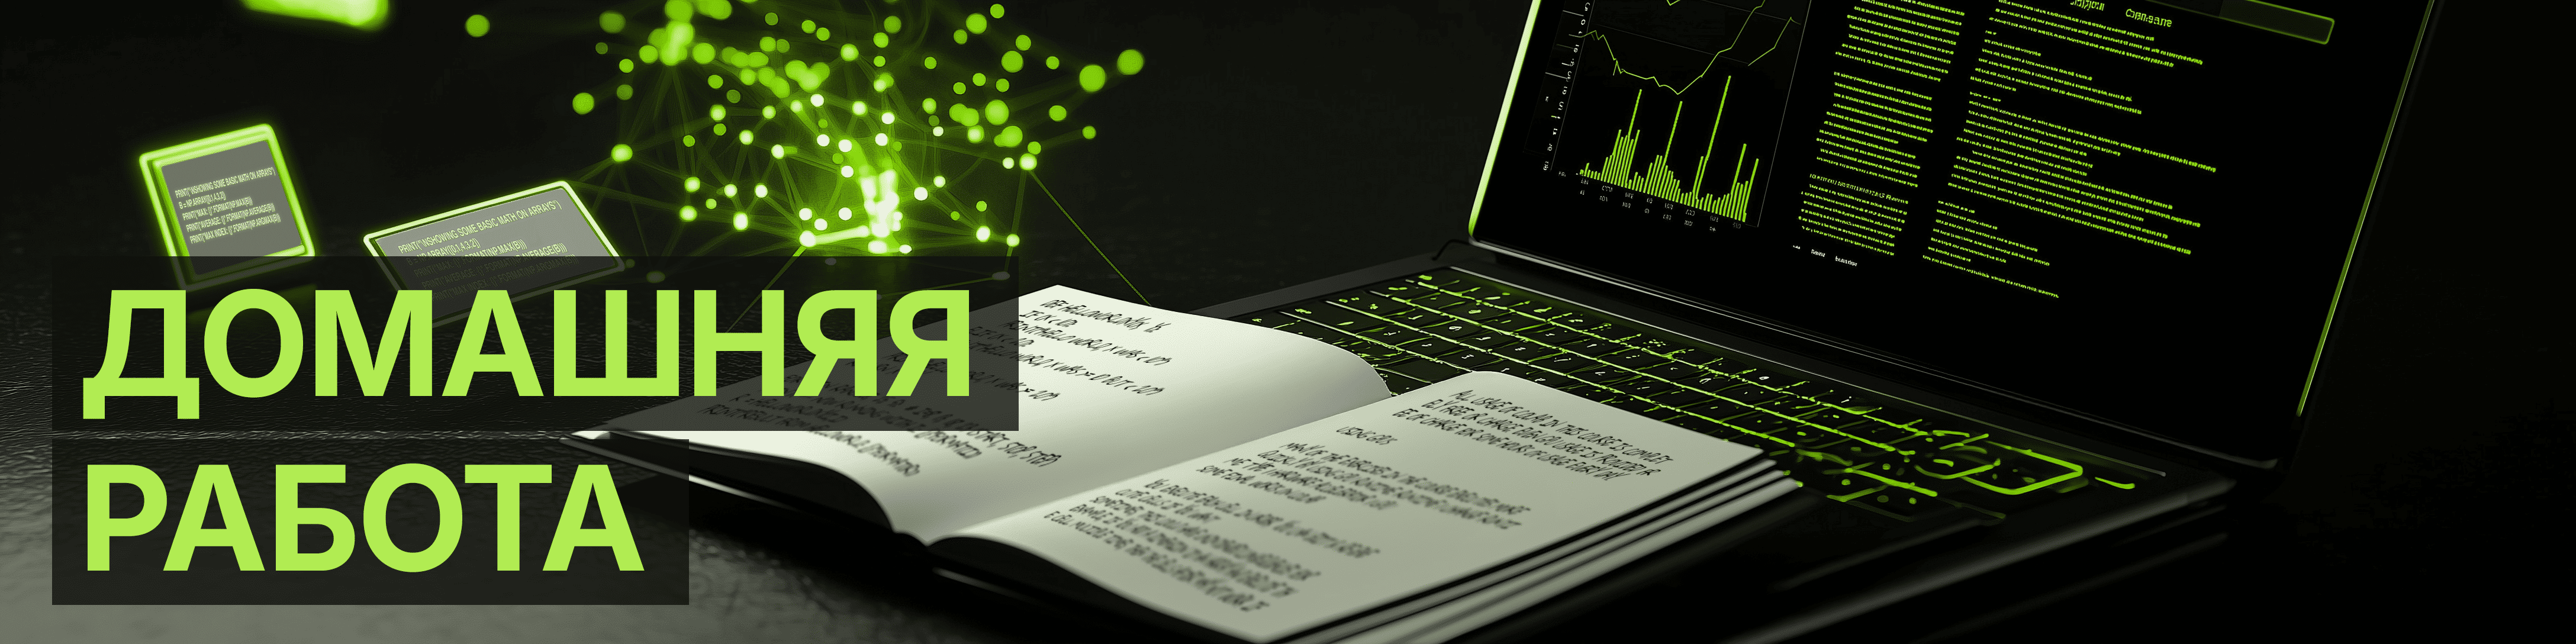

**Навигация по уроку**

1. [Keras v3. Современные подходы к CV (компьютерное зрение)](https://colab.research.google.com/drive/16ks3VjO38c7N4kXUsrdzUbunJOxRu3Fq)
2. [Перенос обучения в Keras 3.0](https://colab.research.google.com/drive/1x2qd4MvG3ODgNrE2uqxRAZB70dGgdGft)
3. [Знакомство с KerasCV](https://colab.research.google.com/drive/1ZWfrEDQaQqDmVUF0yk7N4yoMHRkXf9K-)
4. Домашняя работа

В домашней работе вам необходимо, используя пример из урока 19.2 и Keras 3, произвести тонкую настройку модели второй версии [EfficientNetV2](https://keras.io/api/applications/efficientnet_v2/) на примере набора данных [Stanford Dogs](https://storage.yandexcloud.net/academy.ai/stanford_dogs.zip).

Баллы за задание начисляются следующим образом:
* 3 балла - дается за успешно выполненное задание с точностью на проверочной выборке не менее 75%, в задании должна быть проведена аугментация данных.
* Для получения 4-х баллов необходимо добиться, чтобы точности на проверочной и тестовой выборках были выше 75%.
* Для получения 5-ти баллов необходимо случайным образом отобрать 10 пород собак, выполнить аугментацию и добиться точности как на обучающей, так и проверочной выборках более 85%.  

Keras version: 3.13.2
TensorFlow version: 2.20.0
GPU не доступен
File ‘stanford_dogs.zip’ already there; not retrieving.

Проверка целостности изображений...
Удалено поврежденных изображений: 10
Количество классов (пород): 120

Загрузка датасета...
Found 20570 files belonging to 120 classes.
Using 14399 files for training.
Using 6171 files for validation.

Настройка аугментации данных...

Визуализация аугментированных изображений...


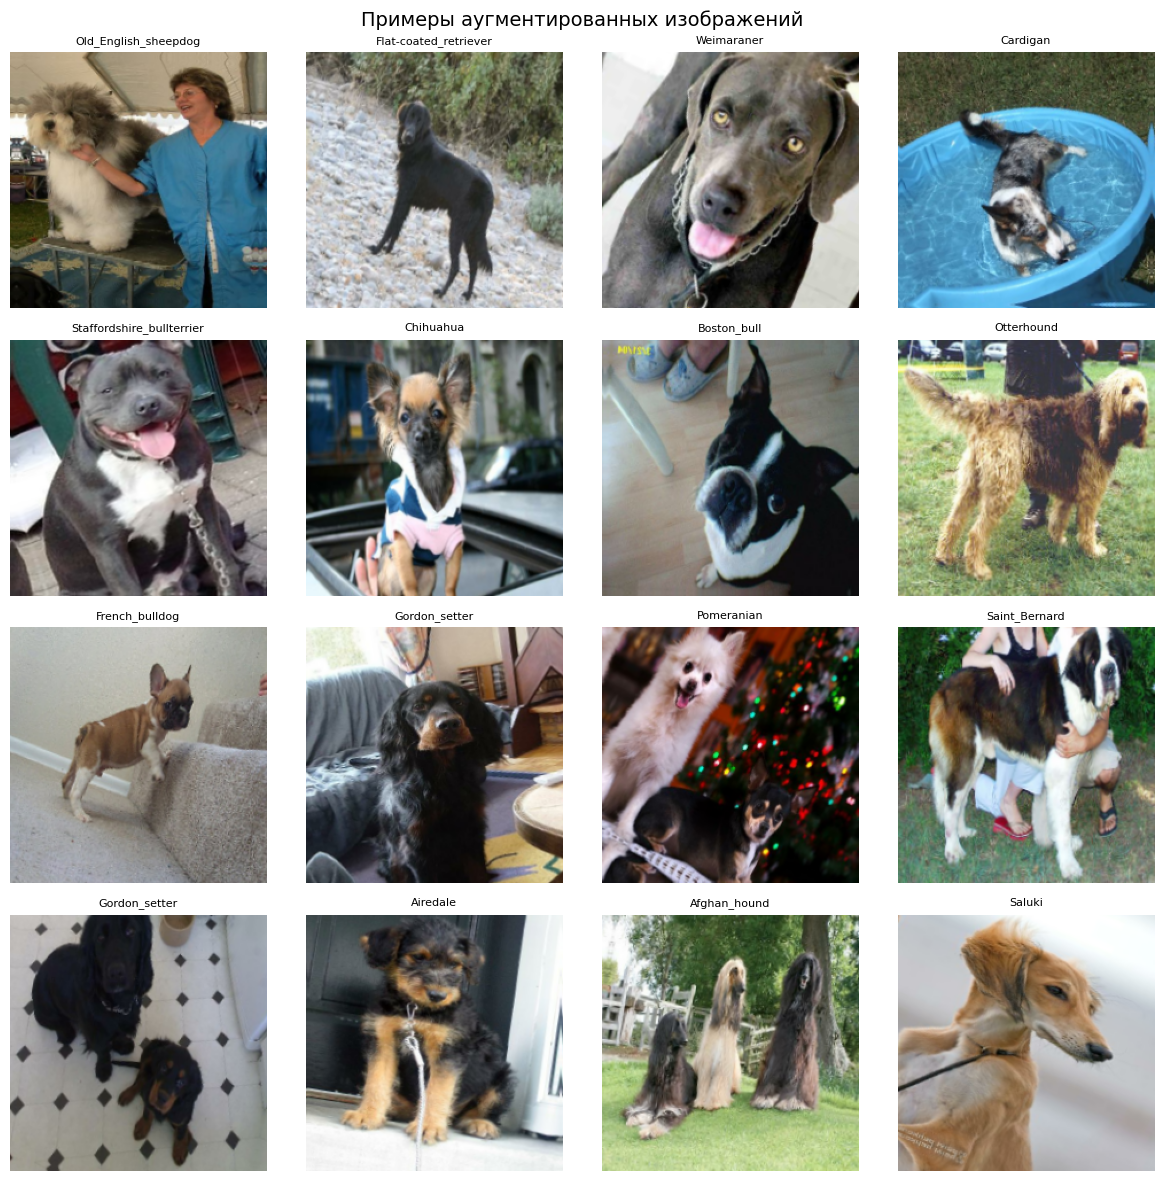


Сборка модели...


Model: "EfficientNetV2B0_StanfordDogs"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 120)            │       153,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,078,152 (23.19 MB)

 Trainable params: 156,280 (610.47 KB)

 Non-trainable params: 5,921,872 (22.59 MB)


Этап 1: Извлечение признаков
Epoch 1/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - acc: 0.5705 - loss: 2.2771 
Epoch 1: val_acc improved from None to 0.82221, saving model to best_model_stage1.keras

Epoch 1: finished saving model to best_model_stage1.keras

Достигнута целевая точность 75% на эпохе 1
113/113 ━━━━━━━━━━━━━━━━━━━━ 1553s 14s/step - acc: 0.6595 - loss: 1.8451 - val_acc: 0.8222 - val_loss: 0.5859 - learning_rate: 0.0100
Restoring model weights from the end of the best epoch: 1.

Результаты этапа 1:
Лучшая точность на валидации: 82.22%

Этап 2: Тонкая настройка
Разморожено 20 верхних слоев (кроме BatchNormalization)
Epoch 1/3
 26/113 ━━━━━━━━━━━━━━━━━━━━ 17:05 12s/step - acc: 0.7881 - loss: 0.9672

In [ ]:
# Решение

# Импорт библиотек и проверка версий
import os
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
from keras.applications import EfficientNetV2B0

%matplotlib inline

print(f"Keras version: {keras.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print("GPU доступен:" if tf.config.list_physical_devices('GPU') else "GPU не доступен")

# Константы
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 128                  # Увеличен для ускорения
EPOCHS_STAGE1 = 8                 # Уменьшено с 15 до 8
EPOCHS_STAGE2 = 3                 # Уменьшено с 5 до 3
VALIDATION_SPLIT = 0.3
TEST_SPLIT = 0.1

# Загрузка данных
!wget -nc https://storage.yandexcloud.net/academy.ai/stanford_dogs.zip
!unzip -qo stanford_dogs.zip -d ./dataset

DATA_PATH = './dataset/'

# Очистка от битых изображений
print("Проверка целостности изображений...")
num_skipped = 0
for folder_name in os.listdir(DATA_PATH):
    folder_path = os.path.join(DATA_PATH, folder_name)
    if not os.path.isdir(folder_path):
        continue
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
            fobj.close()
        except Exception:
            is_jfif = False
        if not is_jfif:
            num_skipped += 1
            os.remove(fpath)

print(f"Удалено поврежденных изображений: {num_skipped}")

class_names = sorted([d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))])
NUM_CLASSES = len(class_names)
print(f"Количество классов (пород): {NUM_CLASSES}")

# Загрузка датасета
print("\nЗагрузка датасета...")

full_ds = keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="both",
    seed=42,
    shuffle=True,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

train_ds_raw = full_ds[0]

val_ds_raw = full_ds[1]
val_batches = len(val_ds_raw)
test_batches = int(val_batches * (TEST_SPLIT / VALIDATION_SPLIT))
val_batches_final = val_batches - test_batches

val_ds_raw = val_ds_raw.take(val_batches_final)
test_ds_raw = val_ds_raw.skip(val_batches_final)

# Аугментация данных
print("\nНастройка аугментации данных...")

augmentation_model = keras.Sequential([
    layers.RandomFlip(mode="horizontal"),
    layers.RandomRotation(factor=0.1, fill_mode='reflect'),
    layers.RandomZoom(height_factor=(-0.1, 0.1)),
], name="augmentation")

augmentation_model.build(input_shape=(None, *IMAGE_SIZE, 3))

def apply_augmentation(images):
    return augmentation_model(images, training=True)

train_ds = train_ds_raw.map(
    lambda img, label: (apply_augmentation(img), keras.ops.one_hot(label, NUM_CLASSES)),
    num_parallel_calls=tf.data.AUTOTUNE,
    deterministic=False
)

val_ds = val_ds_raw.map(
    lambda img, label: (img, keras.ops.one_hot(label, NUM_CLASSES)),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds_raw.map(
    lambda img, label: (img, keras.ops.one_hot(label, NUM_CLASSES)),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# Визуализация аугментированных изображений
print("\nВизуализация аугментированных изображений...")

plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        img_display = keras.utils.img_to_array(images[i]).astype("uint8")
        plt.imshow(img_display)
        label_idx = keras.ops.argmax(labels[i])
        plt.title(class_names[label_idx], fontsize=8)
        plt.axis("off")
plt.suptitle("Примеры аугментированных изображений", fontsize=14)
plt.tight_layout()
plt.show()

# Сборка модели
print("\nСборка модели...")

def build_model():
    base_model = EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMAGE_SIZE, 3)
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(*IMAGE_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Dropout(0.2, name="dropout_1")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)

    model = keras.Model(inputs, outputs, name="EfficientNetV2B0_StanfordDogs")
    return model

model = build_model()
model.summary()

# Колбэки
def get_callbacks(stage_name, patience=3):
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=f'best_model_{stage_name}.keras',
            monitor='val_acc',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1
        )
    ]

# Колбэк для остановки при достижении цели
class StopOnTarget(keras.callbacks.Callback):
    def __init__(self, target=0.75):
        super().__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_acc', 0) >= self.target:
            print(f"\nДостигнута целевая точность {self.target:.0%} на эпохе {epoch+1}")
            self.model.stop_training = True

# Этап 1: Извлечение признаков
print("\n" + "="*60)
print("Этап 1: Извлечение признаков")
print("="*60)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-2),
    loss="categorical_crossentropy",
    metrics=["acc"]
)

history_stage1 = model.fit(
    train_ds,
    epochs=EPOCHS_STAGE1,
    validation_data=val_ds,
    callbacks=get_callbacks("stage1") + [StopOnTarget(target=0.75)],
    verbose=1
)

print(f"\nРезультаты этапа 1:")
print(f"Лучшая точность на валидации: {max(history_stage1.history['val_acc']):.2%}")

# Этап 2: Тонкая настройка
print("\n" + "="*60)
print("Этап 2: Тонкая настройка")
print("="*60)

def unfreeze_model(model, num_layers=20):
    base_model = model.layers[1]

    for layer in base_model.layers[-num_layers:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=["acc"]
    )

    print(f"Разморожено {num_layers} верхних слоев (кроме BatchNormalization)")

unfreeze_model(model, num_layers=20)

history_stage2 = model.fit(
    train_ds,
    epochs=EPOCHS_STAGE2,
    validation_data=val_ds,
    callbacks=get_callbacks("stage2", patience=2) + [StopOnTarget(target=0.75)],
    verbose=1
)

print(f"\nРезультаты этапа 2:")
print(f"Лучшая точность на валидации: {max(history_stage2.history['val_acc']):.2%}")

# Визуализация результатов обучения
print("\nВизуализация графиков обучения...")

def plot_training_history(histories, titles, figsize=(14, 10)):
    fig, axes = plt.subplots(len(histories), 2, figsize=figsize)

    if len(histories) == 1:
        axes = [axes]

    for idx, (history, title) in enumerate(zip(histories, titles)):
        ax1 = axes[idx][0] if len(histories) > 1 else axes[idx][0]
        ax1.plot(history.history['acc'], label='Train Accuracy', linewidth=2)
        ax1.plot(history.history['val_acc'], label='Validation Accuracy', linewidth=2)
        ax1.set_title(f'{title} - Accuracy', fontsize=12)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        ax2 = axes[idx][1] if len(histories) > 1 else axes[idx][1]
        ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
        ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
        ax2.set_title(f'{title} - Loss', fontsize=12)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

combined_history = history_stage1.history.copy()
for key, value in history_stage2.history.items():
    if key in combined_history:
        combined_history[key] = combined_history[key] + value
    else:
        combined_history[key] = value

plot_training_history(
    [history_stage1, history_stage2],
    ["Этап 1: Извлечение признаков", "Этап 2: Тонкая настройка"]
)

# Оценка модели
print("\n" + "="*60)
print("Оценка модели на выборках")
print("="*60)

if os.path.exists('best_model_stage2.keras'):
    print("Загрузка лучшей модели с этапа 2...")
    model = keras.models.load_model('best_model_stage2.keras')

train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print(f"\nРезультаты:")
print(f"Обучающая выборка:   Accuracy = {train_acc:.2%}, Loss = {train_loss:.4f}")
print(f"Валидационная выборка: Accuracy = {val_acc:.2%}, Loss = {val_loss:.4f}")
print(f"Тестовая выборка:    Accuracy = {test_acc:.2%}, Loss = {test_loss:.4f}")

# Проверка условий
print("\n" + "="*60)
print("Проверка условий")
print("="*60)

condition_1 = val_acc >= 0.75
condition_2 = test_acc >= 0.75

print(f"1. Точность на валидации >= 75%: {val_acc:.2%} -> {'ДА' if condition_1 else 'НЕТ'}")
print(f"2. Точность на тесте >= 75%:     {test_acc:.2%} -> {'ДА' if condition_2 else 'НЕТ'}")

if condition_1 and condition_2:
    print("\n" + "="*60)
    print("Условия выполнены! 4 балла")
    print("="*60)
else:
    print("\n" + "="*60)
    print("Условия не выполнены")
    print("="*60)
    print("Рекомендации:")
    print("1. Увеличить EPOCHS_STAGE1 до 10-12")
    print("2. Уменьшить BATCH_SIZE до 64")
    print("3. Добавить RandomContrast в аугментацию")

# Демонстрация предсказаний
print("\nДемонстрация предсказаний на тестовой выборке...")

def show_predictions(model, dataset, class_names, num_images=9):
    plt.figure(figsize=(12, 12))

    for images, labels in dataset.take(1):
        predictions = model.predict(images, verbose=0)

        for i in range(min(num_images, len(images))):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(keras.utils.img_to_array(images[i]).astype("uint8"))

            true_label = class_names[keras.ops.argmax(labels[i])]
            pred_label = class_names[keras.ops.argmax(predictions[i])]
            confidence = keras.ops.max(predictions[i])

            color = 'green' if true_label == pred_label else 'red'

            plt.title(f"True: {true_label[:20]}\nPred: {pred_label[:20]}\nConf: {confidence:.1%}",
                     color=color, fontsize=9)
            plt.axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(model, test_ds, class_names, num_images=9)

# Сохранение результатов
print("\nСохранение результатов...")

model.save('final_model_stanford_dogs.keras')
print("Модель сохранена как 'final_model_stanford_dogs.keras'")

import pandas as pd

history_df = pd.DataFrame({
    'epoch': range(1, len(combined_history['acc']) + 1),
    'train_acc': combined_history['acc'],
    'val_acc': combined_history['val_acc'],
    'train_loss': combined_history['loss'],
    'val_loss': combined_history['val_loss']
})
history_df.to_csv('training_history.csv', index=False)
print("История обучения сохранена в 'training_history.csv'")

print("\n" + "="*60)
print("Итоговая статистика")
print("="*60)
print(f"Модель: EfficientNetV2B0")
print(f"Количество классов: {NUM_CLASSES}")
print(f"Размер изображений: {IMAGE_SIZE}")
print(f"Размер батча: {BATCH_SIZE}")
print(f"Эпох (этап 1): {EPOCHS_STAGE1}")
print(f"Эпох (этап 2): {EPOCHS_STAGE2}")
print(f"\nИтоговая точность:")
print(f"Обучающая выборка: {train_acc:.2%}")
print(f"Валидационная выборка: {val_acc:.2%}")
print(f"Тестовая выборка: {test_acc:.2%}")
print("="*60)

**Примечание**. В 2021 году появилась вторая версия модели EfficientNetV2 (https://arxiv.org/pdf/2104.00298.pdf), которая была добавлена в Keras.